# RoBERTa

## RoBERTa fine-tuning on SEND transcripts to predict affective valence in text

In [1]:
import os
import pandas as pd
import numpy as np
from transformers import RobertaTokenizer
from model_send_text import preprocess_text_data, load_text_inputs
from model_send_text import load_roberta_path, run_roberta

### 1. Preprocess text inputs

#### Supplementary Table 8

Preprocess data from the Stanford Emotional Narratives Dataset (SEND). Data (not included in this repo) were collected and annotated as described in Ong et al. (2021), and were provided by Dr. Ong to be used in accordance with the end-user license agreement. The subset of the data with available video clips are preprocessed into transcript inputs that can be used to fine-tune a text-based model. Models are fine-tuned to predict the labels for affective valence in the SEND dataset averaged within 10-, 20-, and 30-second windows. The original splits for train, validation, and test sets in the Ong et al. paper are preserved here.

In [2]:
segment_duration_levels = [30, 20, 10]

In [3]:
for segment_duration in segment_duration_levels:
    preprocess_text_data("data/raw/with-video/text", "data/raw/ratings", segment_duration, 
                         splits=["train", "valid", "test"])

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of texts:     263
Max words/text:      136
Median words/text:   77
Mean words/text:     76.93
Std dev words/text:  23.37

VALID SPLIT
Number of texts:     133
Max words/text:      112
Median words/text:   74
Mean words/text:     71.49
Std dev words/text:  24.13

TEST SPLIT
Number of texts:     152
Max words/text:      131
Median words/text:   87
Mean words/text:     84.25
Std dev words/text:  21.76

----------------------------------------------------------------------------------------------------
20-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of texts:     387
Max words/text:      94
Median words/text:   53
Mean words/text:     52.28
Std dev words/text:  15.96

VA

### 2. Specify training parameters

Input data are segmented over different time windows (10-, 20-, and 30-second segments). Hyperparameters tuned here are dropout levels.

In [4]:
model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
max_length = 100
n_epochs_levels = [50]
hidden_dropout_levels = [0, 0.1, 0.4]
attn_dropout_levels = [0, 0.1, 0.4]
clf_dropout_levels = [0, 0.1, 0.4]
constant_params = {"lr": 0.00005, 
                   "tune_layer": 11, 
                   "batch_size": 1, 
                   "warmup_steps": 500,
                   "device": "mps:0"}
validation_splits = ["train", "valid"]

### 3. Train models over a range of hyperparameters

In [5]:
validation = []
for segment_duration in segment_duration_levels:
        
    inputs = load_text_inputs("data/texts", segment_duration, tokenizer,
                            max_length=max_length, splits=validation_splits)

    for n_epochs in n_epochs_levels:
        for hidden_dropout in hidden_dropout_levels:
            for attn_dropout in attn_dropout_levels:
                for clf_dropout in clf_dropout_levels:
                        
                    try:
                        model_path, model_eval = run_roberta(model_name, tokenizer, inputs,
                                                             segment_duration=segment_duration,
                                                             n_epochs=n_epochs,
                                                             hidden_dropout=hidden_dropout,
                                                             attn_dropout=attn_dropout,
                                                             clf_dropout=clf_dropout,
                                                             **constant_params,
                                                             splits=validation_splits,
                                                             plot=False)
                    
                        validation += model_eval  
                        df = pd.DataFrame(validation)
                        df = df.sort_values(["segment_duration", "split", "ccc"], ascending=[True, True, False])
                        df.to_csv(f"tables/{model_name}_validation.csv", index=False)
                    
                    except:
                        print("Skipped due to error")

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------

TOKENIZING TEXTS


Map:   0%|          | 0/263 [00:00<?, ? examples/s]

Map:   0%|          | 0/132 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

VALID   Mean: 0.54771   SD: 0.15378   RMSE: 0.23458   R: 0.24497 (p=0.00000)   CCC: 0.22756 (p=0.00000)

----------------------------------------------------------------------------------------------------



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/10s/roberta-base/roberta-base_10s_epochs50_lr5e-05_drop-hidden0.4_drop-attn0.4_drop-clf0.4_tune11

EVALUATING MODEL


TRAIN   Mean: 0.54271   SD: 0.13172   RMSE: 0.20764   R: 0.44123 (p=0.00000)   CCC: 0.38154 (p=0.00000)


VALID   Mean: 0.52715   SD: 0.12414   RMSE: 0.22660   R: 0.19843 (p=0.00014)   CCC: 0.17112 (p=0.00000)

----------------------------------------------------------------------------------------------------



### 4. Select model by validation set performance

In [6]:
valid_params = {}
for segment_duration in segment_duration_levels:
    
    segment_df = df[df["segment_duration"] == segment_duration]
    top_df = segment_df[segment_df["split"] == "valid"].sort_values("ccc", ascending=False)
    top_dict = top_df.to_dict(orient="records")[0]
    
    valid_params[segment_duration] = {"n_epochs": top_dict["n_epochs"],
                                      "hidden_dropout": top_dict["hidden_dropout"],
                                      "attn_dropout": top_dict["attn_dropout"],
                                      "clf_dropout": top_dict["clf_dropout"]}
    
    print("-"*100 + f"\nTOP MODELS FOR {segment_duration}-SECOND SEGMENTS\n")
    print(top_df[["n_epochs", "hidden_dropout", "attn_dropout", "clf_dropout", "ccc", "ccc_p"]])
    print()

----------------------------------------------------------------------------------------------------
TOP MODELS FOR 30-SECOND SEGMENTS

    n_epochs  hidden_dropout  attn_dropout  clf_dropout       ccc  ccc_p
33        50             0.1           0.4          0.1  0.670450    0.0
39        50             0.4           0.0          0.1  0.663495    0.0
17        50             0.0           0.4          0.4  0.646591    0.0
9         50             0.0           0.1          0.1  0.646333    0.0
15        50             0.0           0.4          0.1  0.642612    0.0
29        50             0.1           0.1          0.4  0.639248    0.0
35        50             0.1           0.4          0.4  0.639158    0.0
41        50             0.4           0.0          0.4  0.636504    0.0
19        50             0.1           0.0          0.0  0.635754    0.0
13        50             0.0           0.4          0.0  0.635750    0.0
27        50             0.1           0.1          0.1  0.63

### 5. Evaluate model on the test set

#### Supplementary Tables 9-10

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------

TOKENIZING TEXTS


Map:   0%|          | 0/263 [00:00<?, ? examples/s]

Map:   0%|          | 0/132 [00:00<?, ? examples/s]

Map:   0%|          | 0/152 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/30s/roberta-base/roberta-base_30s_epochs50_lr5e-05_drop-hidden0.1_drop-attn0.4_drop-clf0.1_tune11

EVALUATING MODEL


TRAIN   Mean: 0.56113   SD: 0.24634   RMSE: 0.05030   R: 0.98211 (p=0.00000)   CCC: 0.97737 (p=0.00000)


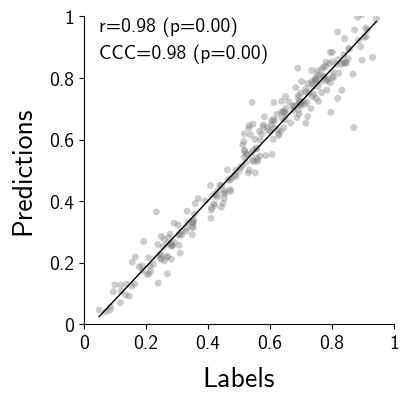

VALID   Mean: 0.55999   SD: 0.18222   RMSE: 0.16574   R: 0.69490 (p=0.00000)   CCC: 0.67045 (p=0.00000)


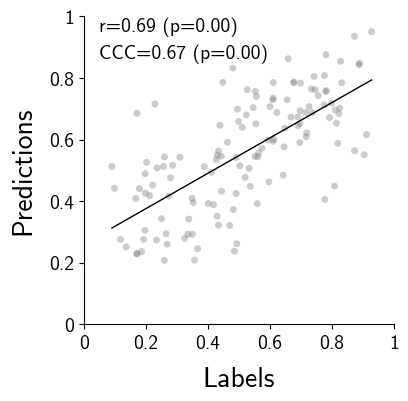

TEST    Mean: 0.53715   SD: 0.18589   RMSE: 0.13677   R: 0.77086 (p=0.00000)   CCC: 0.76410 (p=0.00000)


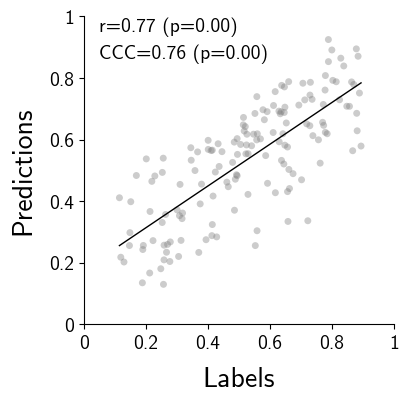


----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
20-SECOND CLIPS
----------------------------------------------------------------------------------------------------

TOKENIZING TEXTS


Map:   0%|          | 0/387 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Map:   0%|          | 0/221 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/20s/roberta-base/roberta-base_20s_epochs50_lr5e-05_drop-hidden0_drop-attn0.4_drop-clf0.1_tune11

EVALUATING MODEL


TRAIN   Mean: 0.53859   SD: 0.23582   RMSE: 0.02676   R: 0.99503 (p=0.00000)   CCC: 0.99337 (p=0.00000)


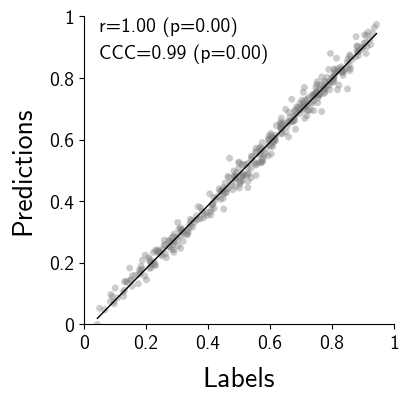

VALID   Mean: 0.53685   SD: 0.16100   RMSE: 0.16860   R: 0.64367 (p=0.00000)   CCC: 0.61191 (p=0.00000)


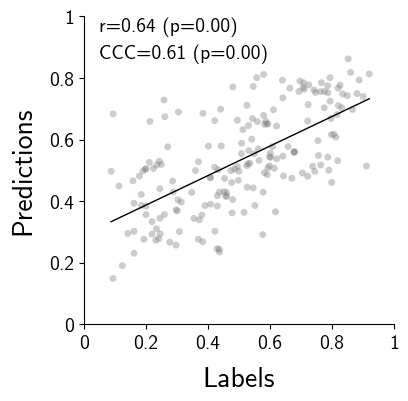

TEST    Mean: 0.54093   SD: 0.17241   RMSE: 0.14692   R: 0.72914 (p=0.00000)   CCC: 0.71257 (p=0.00000)


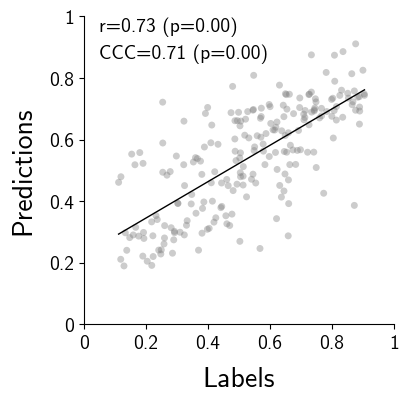


----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
10-SECOND CLIPS
----------------------------------------------------------------------------------------------------

TOKENIZING TEXTS


Map:   0%|          | 0/741 [00:00<?, ? examples/s]

Map:   0%|          | 0/362 [00:00<?, ? examples/s]

Map:   0%|          | 0/431 [00:00<?, ? examples/s]


----------------------------------------------------------------------------------------------------



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/10s/roberta-base/roberta-base_10s_epochs50_lr5e-05_drop-hidden0_drop-attn0.4_drop-clf0.4_tune11

EVALUATING MODEL


TRAIN   Mean: 0.54468   SD: 0.23438   RMSE: 0.03965   R: 0.98565 (p=0.00000)   CCC: 0.98535 (p=0.00000)


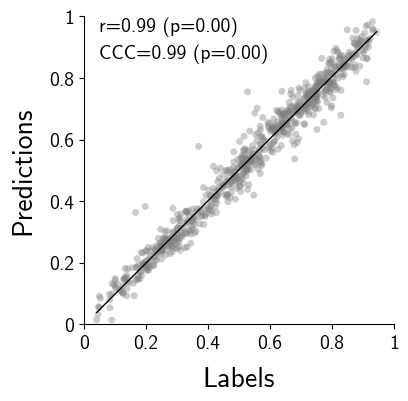

VALID   Mean: 0.54629   SD: 0.16700   RMSE: 0.19831   R: 0.50166 (p=0.00000)   CCC: 0.47829 (p=0.00000)


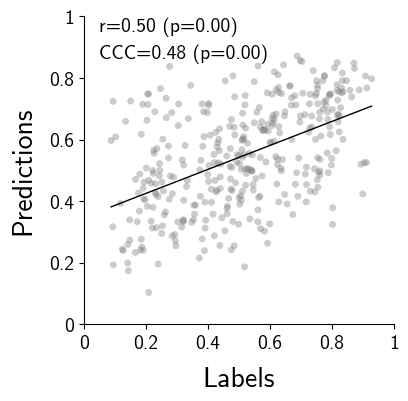

TEST    Mean: 0.55328   SD: 0.16510   RMSE: 0.17928   R: 0.57740 (p=0.00000)   CCC: 0.55703 (p=0.00000)


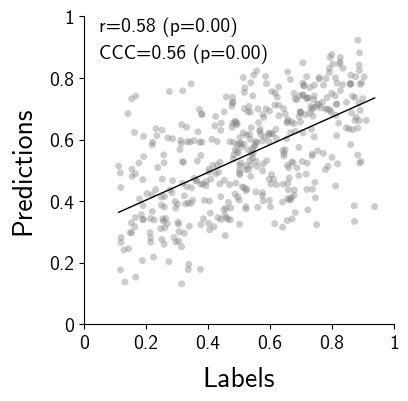


----------------------------------------------------------------------------------------------------



In [8]:
evaluation_splits = ["train", "valid", "test"]
evaluation = []
for segment_duration in segment_duration_levels:
    
    data = load_text_inputs("data/texts", segment_duration, tokenizer,
                            max_length=max_length, splits=evaluation_splits)
    
    model_path, model_eval = run_roberta(model_name, tokenizer, data,
                                         segment_duration=segment_duration,
                                         n_epochs=valid_params[segment_duration]["n_epochs"],
                                         hidden_dropout=valid_params[segment_duration]["hidden_dropout"],
                                         attn_dropout=valid_params[segment_duration]["attn_dropout"],
                                         clf_dropout=valid_params[segment_duration]["clf_dropout"],
                                         **constant_params,
                                         splits=evaluation_splits,
                                         plot=True)

    evaluation += model_eval

evaluation_df = pd.DataFrame(evaluation)
evaluation_df.to_csv(f"tables/{model_name}_evaluation.csv", index=False)